In [1]:
import torch
from torchvision.datasets import MNIST, EMNIST
from torchvision.transforms import ToTensor
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from tqdm import trange, tqdm
import math
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pickle

print('cuda is available?', torch.cuda.is_available())

cuda is available? True


## Plotting functions

In [2]:
def format_number(x):
    if x >= 1e6:
        return f'{x * 1e-6:.0f}M'
    elif x >= 1e3:
        return f'{x * 1e-3:.0f}k'
    else:
        return f'{x:.0f}'

def plot_results(xs, ys, log=False):
    plt.plot(xs, ys)
    plt.grid()
    tirck_formatter = FuncFormatter(lambda x, pos: format_number(x))
    if log:
        plt.yscale('log')
    plt.gca().xaxis.set_major_formatter(tirck_formatter)
    plt.show()

def plot_with_variance(iters, curve_mean, curve_std, log=False):
    plt.plot(iters, curve_mean)
    plt.fill_between(
        iters,
        curve_mean - curve_std,
        curve_mean + curve_std,
        alpha=0.2
    )

    plt.grid()
    tirck_formatter = FuncFormatter(lambda x, pos: format_number(x))
    if log:
        plt.yscale('log')
    plt.gca().xaxis.set_major_formatter(tirck_formatter)
    plt.show()

## Utils

In [3]:
def get_dataset(is_mnist=True, is_train=True):
    dataset = MNIST(root='.', train=is_train, download=False, transform=ToTensor()) if is_mnist \
        else EMNIST(root='.', train=is_train, download=False, transform=ToTensor(), split='letters')
    images = torch.stack([img.view(-1) for img, _ in dataset]).to('cuda')
    return images

X = get_dataset(is_mnist=True, is_train=True)
Y = get_dataset(is_mnist=False, is_train=True)
X_test = get_dataset(is_mnist=True, is_train=False)
Y_test = get_dataset(is_mnist=False, is_train=False)

C = torch.cdist(X_test, Y_test, p=1)

In [4]:
class MLPPotential(nn.Module):
    def __init__(self, input_size=28 * 28, hidden_sizes=(256, 128)):
        super().__init__()
        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.ReLU(),
            ])
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def eval_v(v, Y):
    with torch.no_grad():
        v_vals = v(Y)

    if torch.isnan(v_vals).any() or torch.isinf(v_vals).any():
        print("inf or nan!")
        return None
    return v_vals

def get_batches(X, Y, Nx, Ny, batch_sz):
    indX = torch.randperm(Nx, device='cuda')[:batch_sz]
    indY = torch.randperm(Ny, device='cuda')[:batch_sz]
    return X[indX], Y[indY]

def eval_history_semi(v_history, cost_mat, eps):
    log_Ny = math.log(cost_mat.shape[1])
    objective_vals = []

    for v_vals in v_history:
        exponent = (v_vals.view(-1) - cost_mat) / eps
        lse_term = torch.logsumexp(exponent, dim=1).mean() - log_Ny
        objective_val = v_vals.mean() - eps * lse_term - eps
        objective_vals.append(objective_val.item())

    return objective_vals

## Train loops

In [5]:
def dual_objective(x, y, u, v, eps):
    u_vals, v_vals = u(x), v(y)
    cost_mat = torch.cdist(x, y, p=1)
    exponent = (u_vals + v_vals.view(-1) - cost_mat) / eps
    exp_term = eps * torch.exp(exponent).mean()
    return u_vals.mean() + v_vals.mean() - exp_term

def train_dual(eps, lr, n_iter, n_eval, batch_sz, max_grad, extra_saves=()):
    Nx, Ny = X.shape[0], Y.shape[0]

    v, u = MLPPotential().to('cuda'), MLPPotential().to('cuda')
    optimizer = optim.SGD(list(u.parameters()) + list(v.parameters()), lr=lr)

    v_history = []
    iter_numbers = []

    v_test_vals = eval_v(v, Y_test)
    v_history.append(v_test_vals)
    iter_numbers.append(0)

    pbar = trange(n_iter)
    for i in pbar:
        batch_x, batch_y = get_batches(X, Y, Nx, Ny, batch_sz)
        loss = -dual_objective(batch_x, batch_y, u, v, eps)
        loss.backward()

        clip_grad_norm_(list(u.parameters()) + list(v.parameters()), max_grad)
        optimizer.step()
        optimizer.zero_grad()

        if i in extra_saves or (i + 1) % (n_iter // n_eval) == 0:
            v_test_vals = eval_v(v, Y_test)
            if v_test_vals is None:
                return v_history, iter_numbers
            v_history.append(v_test_vals)
            iter_numbers.append(i)

        pbar.set_postfix({'objective': f'{-loss.item():.2f}'})

    return v_history, iter_numbers

In [6]:
def approx_objective(x, y, v, alpha, eps, rho):
    v_vals = v(y)
    alphas = alpha(x)
    cost_mat = torch.cdist(x, y, p=1)
    exponent = (v_vals.view(-1) - cost_mat - alphas) / eps
    softplus = F.softplus(exponent + math.log(rho)).mean()
    return v_vals.mean() - alphas.mean() - (eps / rho) * softplus


def train_approx(eps, lr, n_iter, n_eval, batch_sz, rho):
    Nx, Ny = X.shape[0], Y.shape[0]

    v, alpha = MLPPotential().to('cuda'), MLPPotential().to('cuda')
    optimizer = optim.SGD(list(v.parameters()) + list(alpha.parameters()), lr=lr)

    v_history = []
    iter_numbers = []

    v_test_vals = eval_v(v, Y_test)
    v_history.append(v_test_vals)
    iter_numbers.append(0)

    pbar = trange(n_iter)
    for i in pbar:
        batch_x, batch_y = get_batches(X, Y, Nx, Ny, batch_sz)
        loss = -approx_objective(batch_x, batch_y, v, alpha, eps, rho)
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        if (i + 1) % (n_iter // n_eval) == 0:
            v_test_vals = eval_v(v, Y_test)
            v_history.append(v_test_vals)
            iter_numbers.append(i)

        pbar.set_postfix({'objective': f'{-loss.item():.2f}'})

    return v_history, iter_numbers

In [7]:
n_iter = 20000
n_eval = 10
batch_sz = 256
max_grad = 10.
n_runs = 5

In [8]:
def run_experiment(eps=1., lr=1e-2, rho=None):
    curves = []

    for seed in range(n_runs):
        torch.manual_seed(seed)
        v_history, iter_numbers = train_dual(eps, lr, n_iter, n_eval, batch_sz, max_grad) \
            if rho is None else train_approx(eps, lr, n_iter, n_eval, batch_sz, rho)
        objective_vals = eval_history_semi(v_history, C, eps)
        curves.append(objective_vals)

    with open(f'curves_eps{eps}{'' if rho is None else f"_rho{rho}"}.pkl', 'wb') as f:
        pickle.dump(curves, f)

    mean_curve = np.mean(curves, axis=0)
    std_curve = np.std(curves, axis=0)
    plot_with_variance(iter_numbers, mean_curve, std_curve)

## Execution

### eps = 1

100%|██████████████████████████████████████████████████████████| 20000/20000 [05:03<00:00, 65.97it/s, objective=107.57]


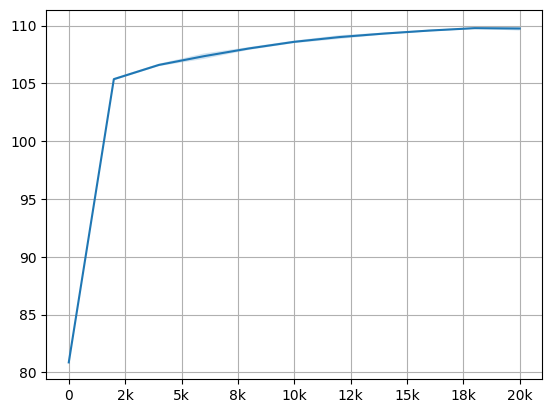

In [9]:
run_experiment(eps=1., lr=1e-2, rho=None)

100%|██████████████████████████████████████████████████████████| 20000/20000 [04:42<00:00, 70.71it/s, objective=135.97]


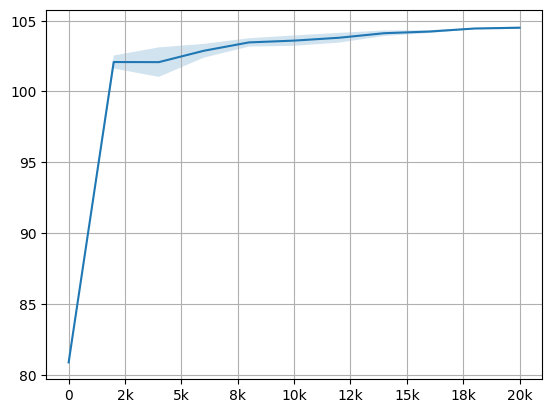

In [10]:
run_experiment(eps=1., lr=1e-2, rho=0.1)

100%|██████████████████████████████████████████████████████████| 20000/20000 [04:20<00:00, 76.84it/s, objective=117.59]


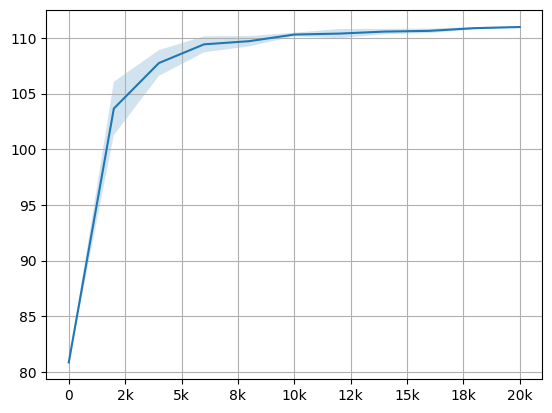

In [11]:
run_experiment(eps=1., lr=1e-2, rho=1e-3)

100%|███████████████████████████████████████████████████████████| 20000/20000 [04:20<00:00, 76.84it/s, objective=92.12]


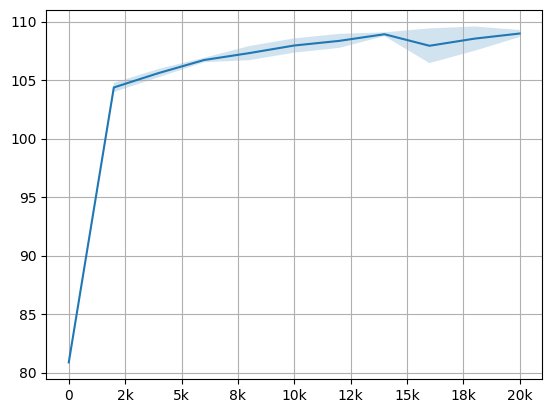

In [12]:
run_experiment(eps=1., lr=1e-3, rho=1e-5)

### eps = 1e-2

100%|████████████████████████████████████████████████████████████| 20000/20000 [04:31<00:00, 73.64it/s, objective=1.19]


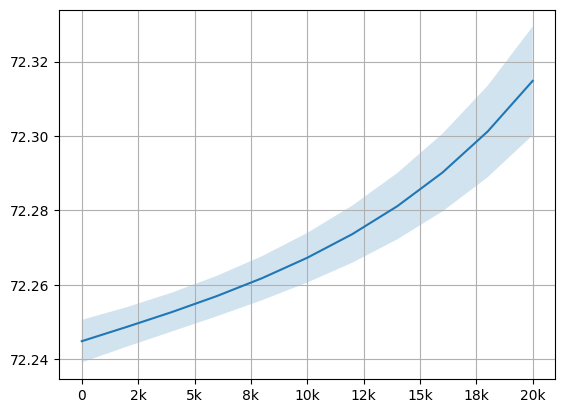

In [13]:
run_experiment(eps=1e-2, lr=1e-5, rho=None)

100%|██████████████████████████████████████████████████████████| 20000/20000 [04:20<00:00, 76.71it/s, objective=133.88]


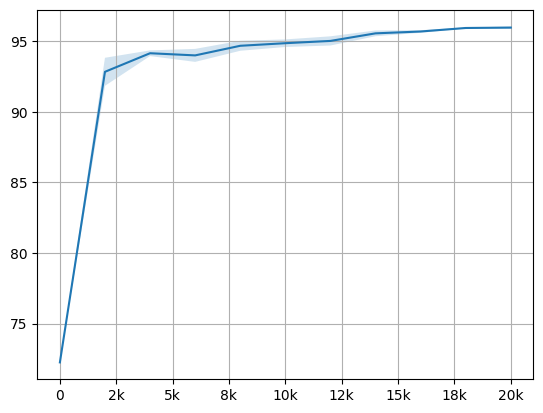

In [14]:
run_experiment(eps=1e-2, lr=1e-2, rho=0.1)

100%|██████████████████████████████████████████████████████████| 20000/20000 [04:20<00:00, 76.88it/s, objective=111.26]


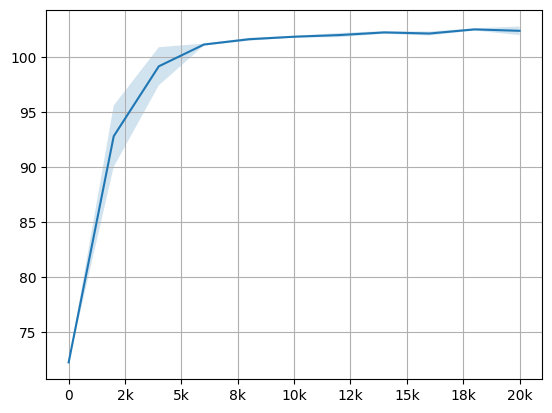

In [15]:
run_experiment(eps=1e-2, lr=1e-2, rho=1e-3)

100%|███████████████████████████████████████████████████████████| 20000/20000 [04:19<00:00, 76.92it/s, objective=91.47]


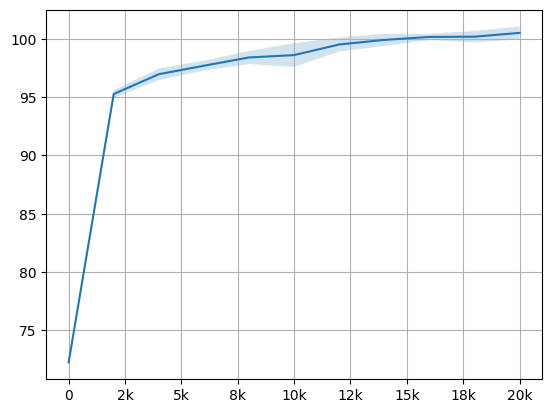

In [16]:
run_experiment(eps=1e-2, lr=1e-3, rho=1e-5)

### eps = 1e-4

100%|████████████████████████████████████████████████████████████| 20000/20000 [04:31<00:00, 73.55it/s, objective=1.19]


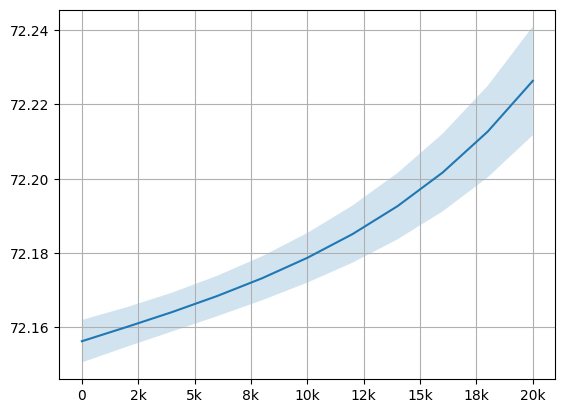

In [17]:
run_experiment(eps=1e-4, lr=1e-5, rho=None)

100%|██████████████████████████████████████████████████████████| 20000/20000 [04:20<00:00, 76.64it/s, objective=133.87]


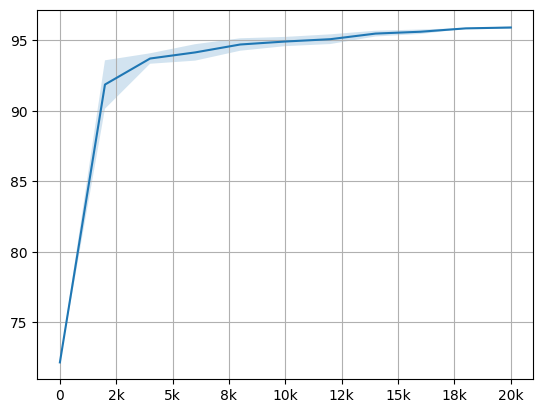

In [18]:
run_experiment(eps=1e-4, lr=1e-2, rho=0.1)

100%|██████████████████████████████████████████████████████████| 20000/20000 [04:20<00:00, 76.84it/s, objective=109.24]


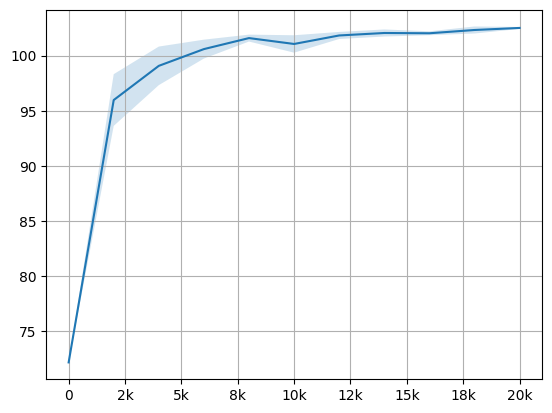

In [19]:
run_experiment(eps=1e-4, lr=1e-2, rho=1e-3)

100%|███████████████████████████████████████████████████████████| 20000/20000 [04:19<00:00, 76.97it/s, objective=94.63]


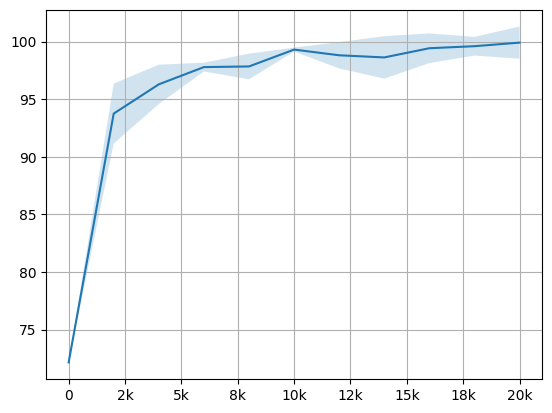

In [20]:
run_experiment(eps=1e-4, lr=1e-3, rho=1e-5)

## Diverging curves for the baseline
**Please note** that the actual iteration number on which an overflow occurs may depend on your system

In [21]:
def check_divergence(eps=1e-2, lr=1e-2, n_iter=10000, n_eval=10, seed=0, extra_saves=()):
    torch.manual_seed(seed)

    v_history, iter_numbers = train_dual(eps, lr, n_iter, n_eval, batch_sz, max_grad, extra_saves=extra_saves)
    objective_vals = eval_history_semi(v_history, C, eps)
    plot_results(iter_numbers, objective_vals)

    with open(f'diverging_eps{eps}_{seed}.pkl', 'wb') as f:
        pickle.dump((iter_numbers, objective_vals), f)

 53%|███████████████████████████████▌                            | 5254/10000 [01:15<01:08, 69.44it/s, objective=36.98]


inf or nan!


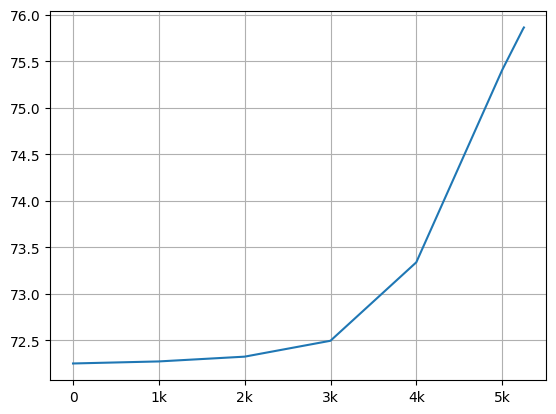

In [33]:
check_divergence(eps=1e-2, lr=1e-4, n_iter=10000, n_eval=10, seed=0, extra_saves=list(range(5244, 5264)))

 51%|██████████████████████████████▊                             | 5142/10000 [01:15<01:11, 67.71it/s, objective=34.70]


inf or nan!


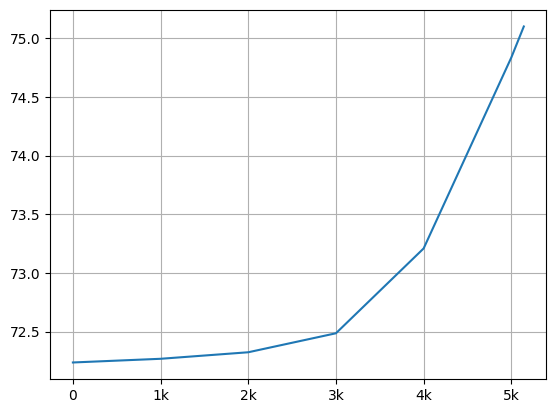

In [37]:
check_divergence(eps=1e-2, lr=1e-4, n_iter=10000, n_eval=10, seed=1, extra_saves=list(range(5130, 5151)))

 51%|██████████████████████████████▊                             | 5130/10000 [01:13<01:10, 69.38it/s, objective=35.24]


inf or nan!


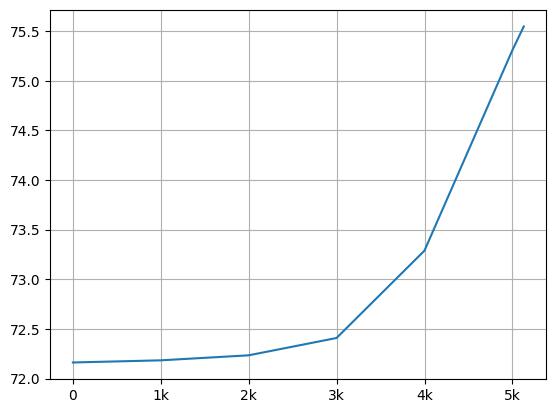

In [42]:
check_divergence(eps=1e-4, lr=1e-4, n_iter=10000, n_eval=10, seed=2, extra_saves=list(range(5125, 5135)))

 54%|████████████████████████████████▏                           | 5366/10000 [01:18<01:07, 68.41it/s, objective=33.55]


inf or nan!


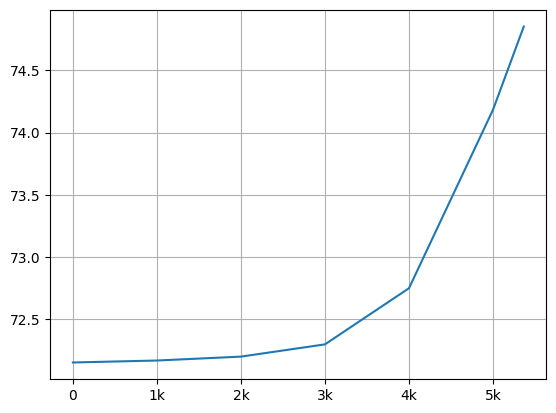

In [39]:
check_divergence(eps=1e-4, lr=1e-4, n_iter=10000, n_eval=10, seed=3, extra_saves=list(range(5360, 5370)))

# Final plots

In [80]:
def format_sci(x):
    exp = int(np.log10(x))
    return f'$10^{{{exp}}}$'
    
def load_curves(eps=1., lr_dual=1e-2):
    iters = list(range(0, 20001, 2000))
    curves = []

    for rho in [0.1, 1e-3, 1e-5]:
        curves_approx = pickle.load(open(f'curves_eps{eps}_rho{rho}.pkl', 'rb'))
        lr = 1e-3 if rho == 1e-5 else 1e-2
        lbl = r'Proposed approach, $\rho=$' + format_sci(rho) + ', ' + f'lr={format_sci(lr)}'
        curves.append((iters, curves_approx, lbl))

    curves_dual = pickle.load(open(f'curves_eps{eps}.pkl', 'rb'))
    curves.append((iters, curves_dual, f'SGD on the dual, lr={format_sci(lr_dual)}'))
    
    dashed_curves = []
    if eps != 1.:
        seeds = [0, 1] if eps == 1e-2 else [2, 3]
        lbl = f'SGD on the dual, lr={format_sci(1e-4)} (overflow)'
        for seed in seeds:
            iters, line = pickle.load(open(f'diverging_eps{eps}_{seed}.pkl', 'rb'))
            dashed_curves.append((iters, line, lbl))

    return curves, dashed_curves

In [91]:
def plot_many_subplots(curves_list, dashed_curves_list, titles, fname, ylims=(None, None), fs=16):
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)
    
    for idx, (curves, dashed_curves, title) in enumerate(zip(curves_list, dashed_curves_list, titles)):
        ax = axes[idx]
        
        for iters, lines, lbl in curves:
            mean = np.mean(lines, axis=0)
            std = np.std(lines, axis=0)
            if lbl.startswith('SGD') and len(dashed_curves) > 0:
                ax.plot(iters, mean, label=lbl, linewidth=3)
            else:
                ax.plot(iters, mean, label=lbl)
            
            ax.fill_between(
                iters,
                mean - std,
                mean + std,
                alpha=0.2
            )
            tirck_formatter = FuncFormatter(lambda x, pos: format_number(x))
            ax.xaxis.set_major_formatter(tirck_formatter)
        
        for i, (iters, line, lbl) in enumerate(dashed_curves):
            ax.plot(iters, line, label=lbl if i == 0 else "", linestyle='--', linewidth=2, color='k')
        
        ax.set_title(title, fontsize=fs)
        ax.set_xlabel('Iteration', fontsize=fs)
        if idx == 0:
            ax.set_ylabel('Objective', fontsize=fs)
        
        ax.tick_params(axis='both', which='major', labelsize=fs)
        ax.set_ylim(ylims)
        ax.grid()
        
        ax.legend(fontsize=fs, loc='lower right', bbox_to_anchor=(0.95, 0.21))
    
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight', dpi=300)
    plt.show()

In [92]:
curves1, dashed_curves1 = load_curves(eps=1., lr_dual=1e-2)
curves2, dashed_curves2 = load_curves(eps=1e-2, lr_dual=1e-5)
curves3, dashed_curves3 = load_curves(eps=1e-4, lr_dual=1e-5)

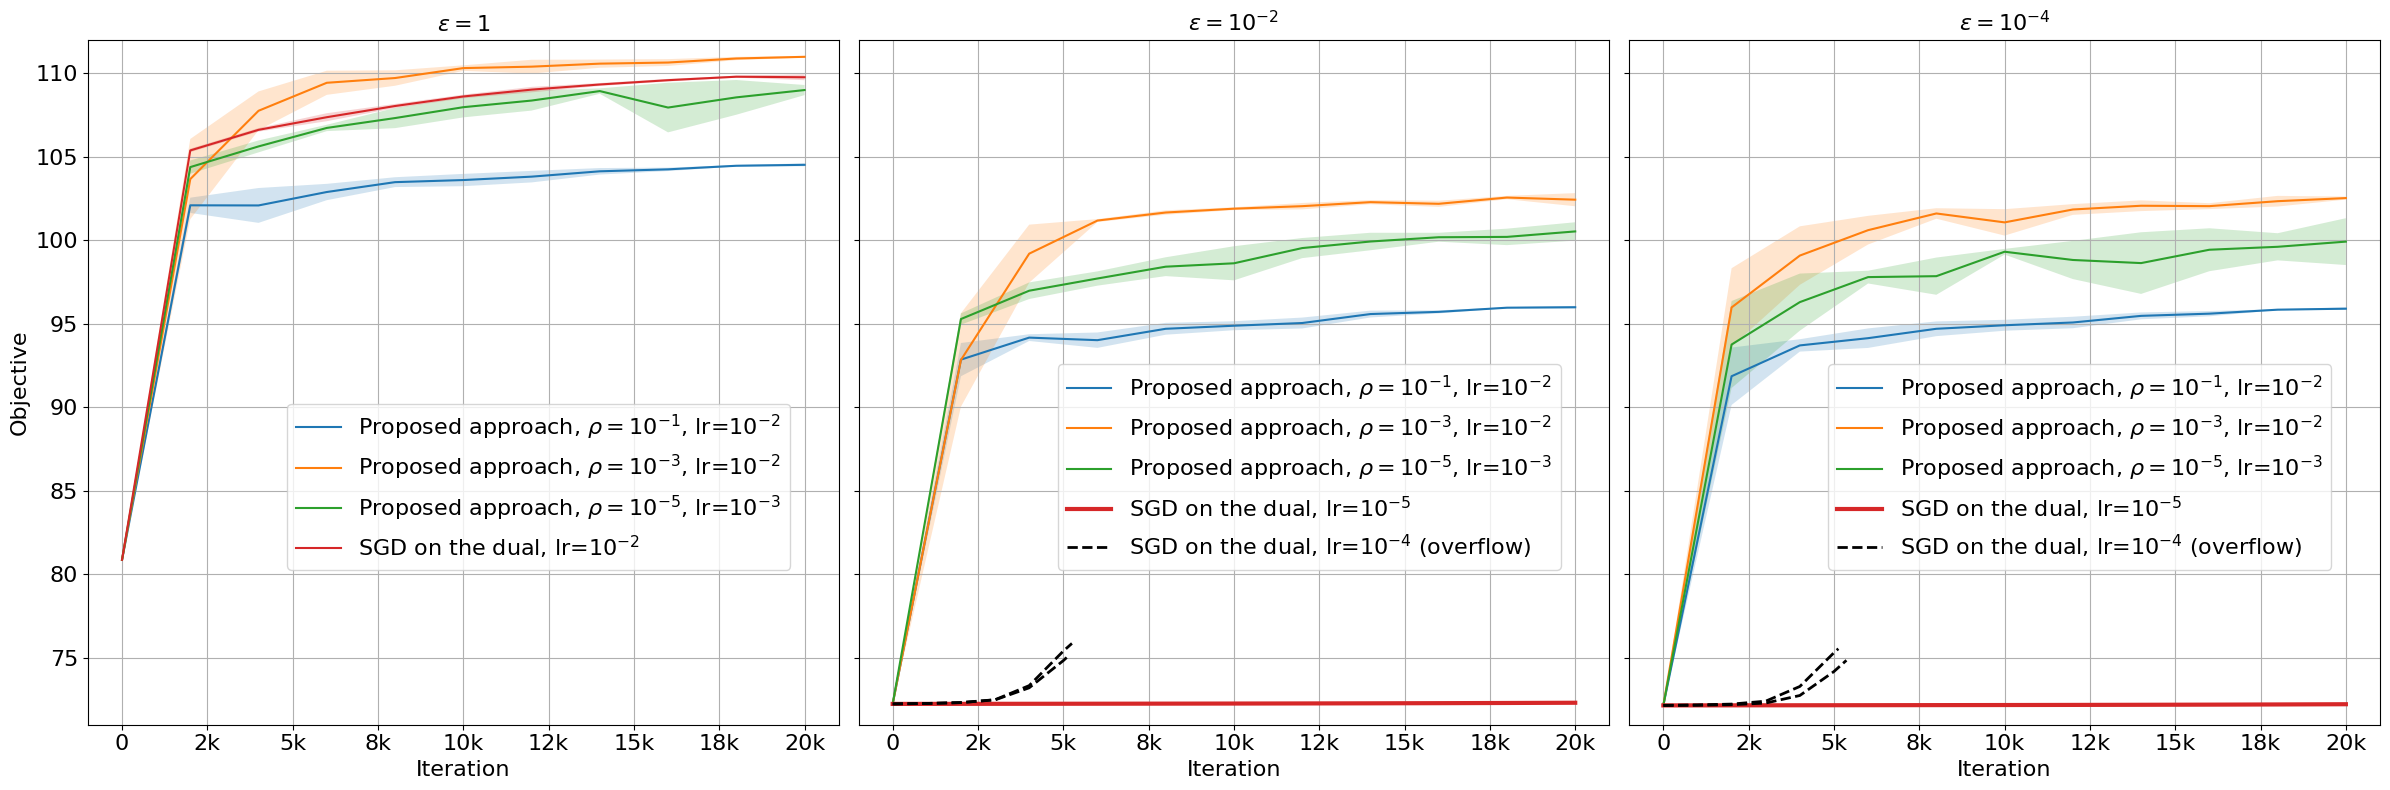

In [93]:
titles = [r'$\varepsilon = 1$',
          r'$\varepsilon = $' + format_sci(1e-2),
          r'$\varepsilon = $' + format_sci(1e-4)]

plot_many_subplots(
    curves_list=[curves1, curves2, curves3],
    dashed_curves_list=[dashed_curves1, dashed_curves2, dashed_curves3],
    titles=titles,
    fname='combined_plots.png',
    ylims=(71, 112)
)